Loading bc: 50 cases, T_START=400, T_END=618
Loading geo: 20 cases, T_START=1000, T_END=1998
Loading prop: 116 cases, T_START=600, T_END=998

Total samples:      10520
Samples per subset: {'bc': 880, 'geo': 3800, 'prop': 5840}
bc: 14 train, 2 val, 4 test
geo: 13 train, 1 val, 5 test
prop visc=0.0001: 8 train, 1 val, 3 test
prop visc=0.0005: 13 train, 2 val, 4 test
prop visc=0.001: 14 train, 3 val, 3 test
prop visc=0.005: 14 train, 3 val, 3 test
prop visc=0.01: 1 train, 0 val, 1 test

Total train cases: 77
Total val cases:   12
Total test cases:  23

Train samples: 7216
Val samples:   1008
Test samples:  2296

Input means per channel: [1.16229346e-02 1.27439026e+02 9.75207210e-01 9.57741082e-01]
Input stds per channel:  [ 0.10717746 82.58508     0.41583887  0.42991763]
U: mean=0.9752, std=0.4158
V: mean=0.9578, std=0.4299

Train samples per subset: {'bc': 616, 'geo': 2600, 'prop': 4000}

Train batches: 226
Val batches:   32
Test batches:  2296
Training on: cuda
Epoch 0, Train Loss: 0.04

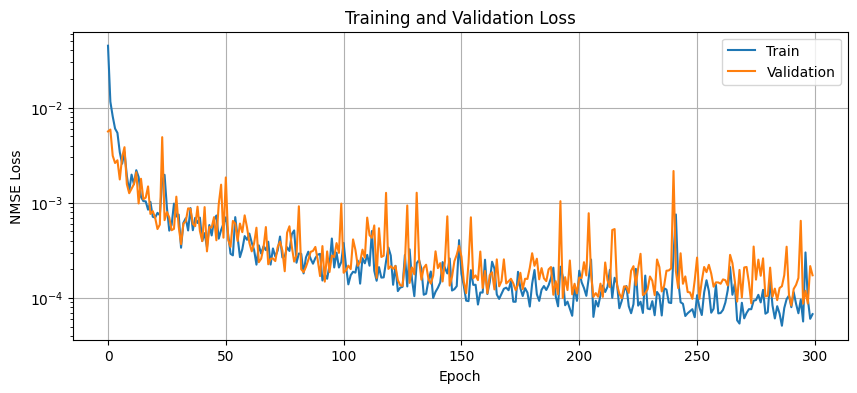


Final Test Results:
Mean test loss: 0.000201
Min test loss:  0.000016
Max test loss:  0.000817
Best val loss:  0.000083
Model saved!
Mean relative error U: 0.34%
Mean relative error V: 0.38%
Max relative error U:  1.14%
Max relative error V:  1.05%
Model vs Identity by Re range:
Re 0-50: Model=0.1141%, Identity=0.0000%, Improvement=-0.1141%
Re 50-100: Model=0.1196%, Identity=0.0002%, Improvement=-0.1194%
Re 100-150: Model=0.2720%, Identity=0.2334%, Improvement=-0.0386%
Re 200-250: Model=0.2205%, Identity=0.4733%, Improvement=0.2528%
Re 250-300: Model=0.2151%, Identity=0.4618%, Improvement=0.2468%
Re 300-350: Model=0.3607%, Identity=0.6736%, Improvement=0.3129%
Re 350-400: Model=0.4512%, Identity=0.6489%, Improvement=0.1978%
Re 400-450: Model=0.5699%, Identity=0.6274%, Improvement=0.0575%


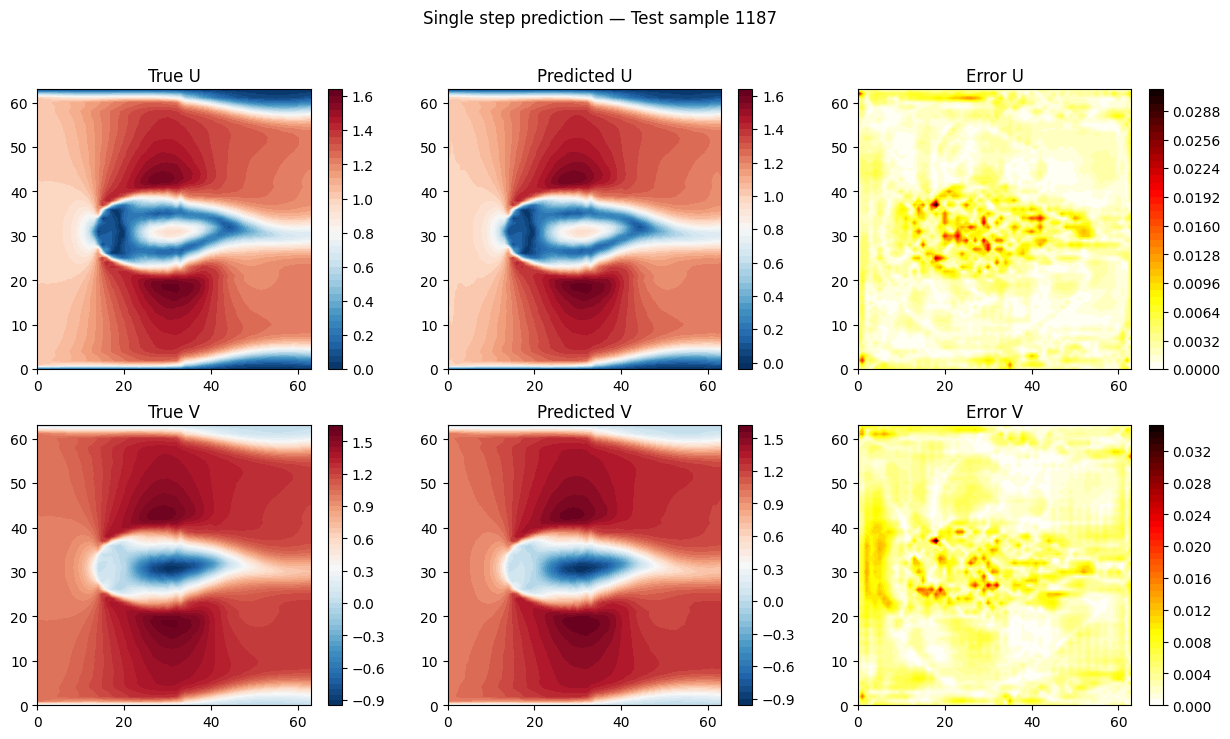

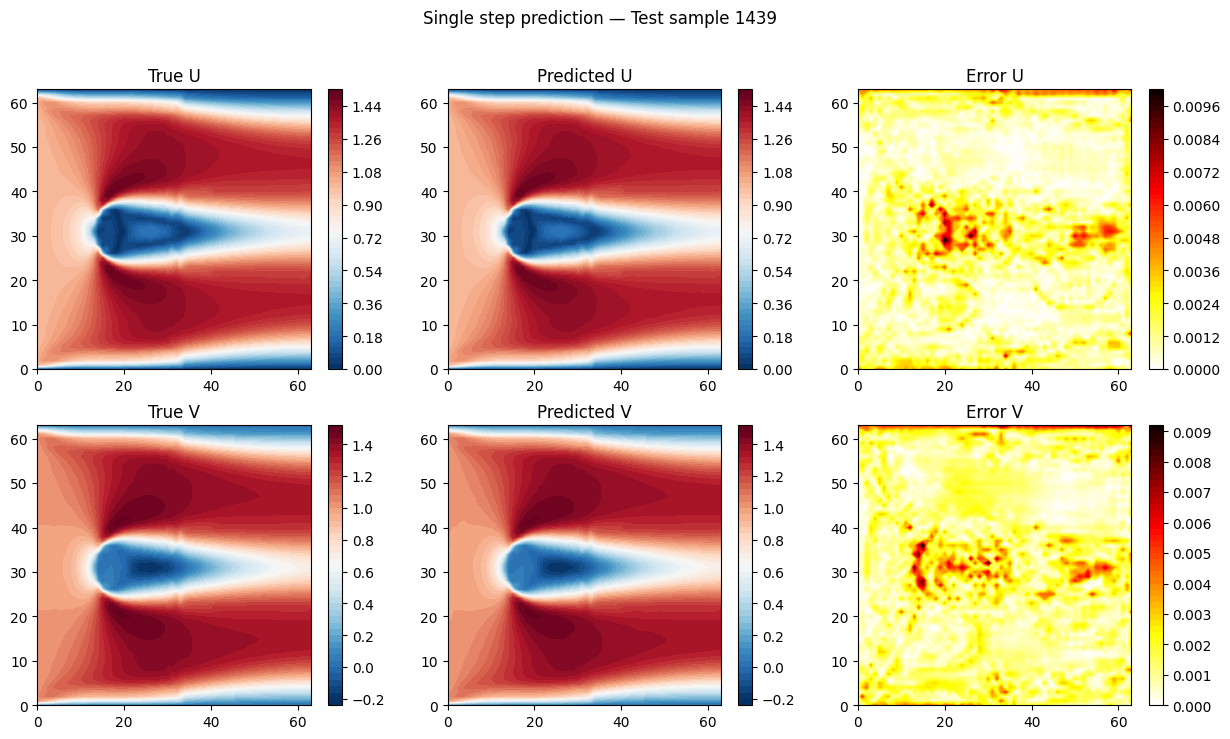

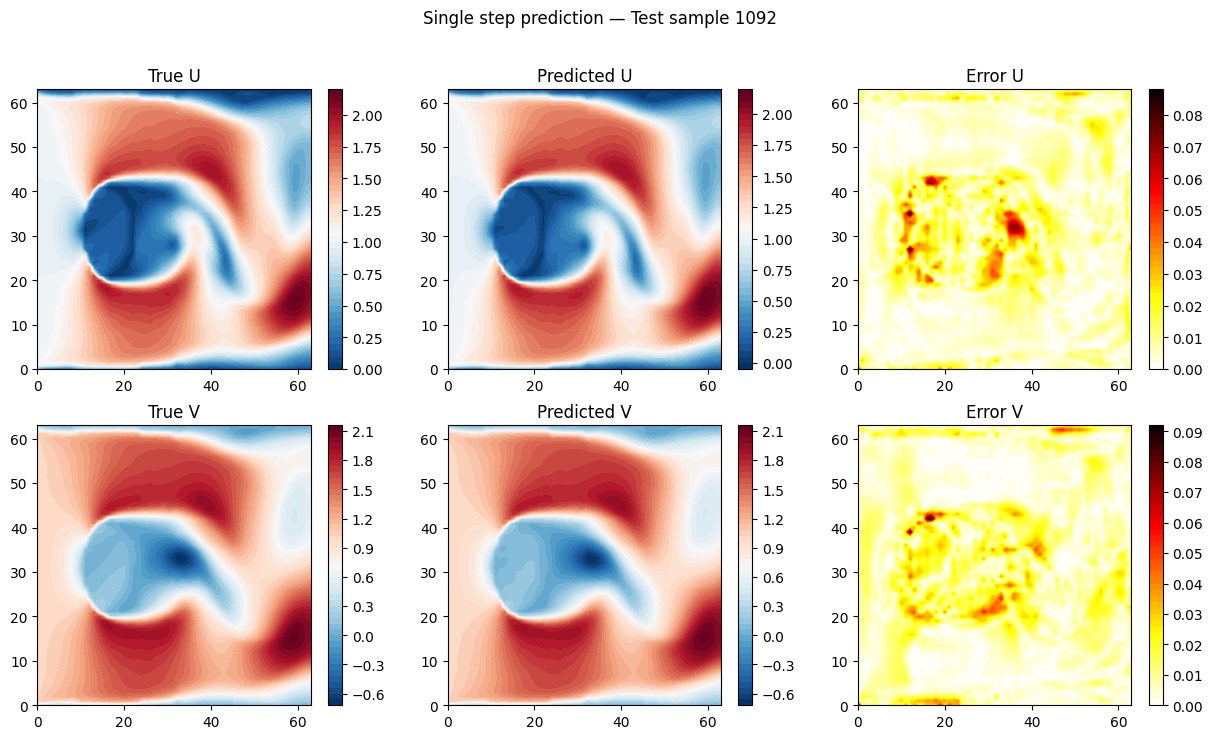

In [6]:
# GIVEN U_T PREDICT U_T+1

import os 
import numpy as np
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.optim as optim
import matplotlib.pyplot as plt
import random

base_path = r'C:\PyTorch\CNN_Cylinder'
subsets = ['bc', 'geo', 'prop']

# Per-subset time parameters
subset_params = {
    'bc':   {'T_START': 400, 'T_END': 618},
    'geo':  {'T_START': 1000, 'T_END': 1998},
    'prop': {'T_START': 600, 'T_END': 998}
}
DELTA_T     = 1
GRID        = 64
SAMPLE_STEP = 5

def create_mask(info, grid_size=GRID):
    x = np.linspace(info['x_min'], info['x_max'], grid_size)
    y = np.linspace(info['y_min'], info['y_max'], grid_size)
    X, Y = np.meshgrid(x, y)
    mask = (X**2 + Y**2 < info['radius']**2).astype(np.float32)
    return mask

# Load all cases
inputs_all  = []
targets_all = []
subset_ids  = []
case_ids    = []
subset_counts = {'bc': 0, 'geo': 0, 'prop': 0}

for subset in subsets:
    subset_path = os.path.join(base_path, subset)
    cases = sorted(os.listdir(subset_path))
    T_START = subset_params[subset]['T_START']
    T_END   = subset_params[subset]['T_END']
    print(f'Loading {subset}: {len(cases)} cases, T_START={T_START}, T_END={T_END}')
    
    for case in cases:
        json_path = os.path.join(subset_path, case, 'case.json')
        with open(json_path, 'r') as f:
            info = json.load(f)
        
        Re      = (info['density'] * info['vel_in'] * 2 * info['radius']) / info['viscosity']
        density = info['density']
        
        if density > 20 or Re > 400:
            continue
        
        mask       = create_mask(info)
        re_channel = np.full((GRID, GRID), Re, dtype=np.float32)
        
        u = np.load(os.path.join(subset_path, case, 'u.npy')) 
        v = np.load(os.path.join(subset_path, case, 'v.npy')) 
        
        for t in range(T_START, T_END, SAMPLE_STEP):
            u_t      = u[t].astype(np.float32)
            v_t      = v[t].astype(np.float32)
            u_t_next = u[t + DELTA_T].astype(np.float32)
            v_t_next = v[t + DELTA_T].astype(np.float32)
            
            inp = np.stack([mask, re_channel, u_t, v_t], axis=0)
            tgt = np.stack([u_t_next, v_t_next], axis=0)
            
            inputs_all.append(inp)
            targets_all.append(tgt)
            subset_ids.append(subset)
            case_ids.append(f'{subset}/{case}')
            subset_counts[subset] += 1

inputs_all  = np.array(inputs_all,  dtype=np.float32)
targets_all = np.array(targets_all, dtype=np.float32)

print(f'\nTotal samples:      {len(inputs_all)}')
print(f'Samples per subset: {subset_counts}')

# Train/val/test split — stratified by subset and viscosity group
unique_cases = list(dict.fromkeys(case_ids))
train_cases  = set()
val_cases    = set()
test_cases   = set()

# BC
bc_case_list = [c for c in unique_cases if c.startswith('bc')]
n = len(bc_case_list)
train_n = int(0.7 * n)
val_n   = int(0.1 * n)
train_cases.update(bc_case_list[:train_n])
val_cases.update(bc_case_list[train_n:train_n+val_n])
test_cases.update(bc_case_list[train_n+val_n:])
print(f'bc: {train_n} train, {val_n} val, {n-train_n-val_n} test')

# GEO
geo_case_list = [c for c in unique_cases if c.startswith('geo')]
n = len(geo_case_list)
train_n = int(0.7 * n)
val_n   = int(0.1 * n)
train_cases.update(geo_case_list[:train_n])
val_cases.update(geo_case_list[train_n:train_n+val_n])
test_cases.update(geo_case_list[train_n+val_n:])
print(f'geo: {train_n} train, {val_n} val, {n-train_n-val_n} test')

# PROP — per viscosity group
prop_by_viscosity = {}
prop_path = os.path.join(base_path, 'prop')
for case in sorted(os.listdir(prop_path)):
    case_key = f'prop/{case}'
    if case_key not in unique_cases:
        continue
    json_path = os.path.join(prop_path, case, 'case.json')
    with open(json_path, 'r') as f:
        info = json.load(f)
    visc = info['viscosity']
    if visc not in prop_by_viscosity:
        prop_by_viscosity[visc] = []
    prop_by_viscosity[visc].append(case_key)

for visc, cases in sorted(prop_by_viscosity.items()):
    n = len(cases)
    train_n = int(0.7 * n)
    val_n   = int(0.15 * n)
    train_cases.update(cases[:train_n])
    val_cases.update(cases[train_n:train_n+val_n])
    test_cases.update(cases[train_n+val_n:])
    print(f'prop visc={visc}: {train_n} train, {val_n} val, {n-train_n-val_n} test')

print(f'\nTotal train cases: {len(train_cases)}')
print(f'Total val cases:   {len(val_cases)}')
print(f'Total test cases:  {len(test_cases)}')

# Rebuild indices
train_idx = [i for i, c in enumerate(case_ids) if c in train_cases]
val_idx   = [i for i, c in enumerate(case_ids) if c in val_cases]
test_idx  = [i for i, c in enumerate(case_ids) if c in test_cases]

inputs_train  = inputs_all[train_idx]
targets_train = targets_all[train_idx]
inputs_val    = inputs_all[val_idx]
targets_val   = targets_all[val_idx]
inputs_test   = inputs_all[test_idx]
targets_test  = targets_all[test_idx]

print(f'\nTrain samples: {len(inputs_train)}')
print(f'Val samples:   {len(inputs_val)}')
print(f'Test samples:  {len(inputs_test)}')

# Normalization — train stats only
input_mean = inputs_train.mean(axis=(0, 2, 3), keepdims=True)
input_std  = inputs_train.std(axis=(0, 2, 3),  keepdims=True)
input_std  = np.where(input_std < 1e-6, 1.0, input_std)

u_mean, u_std = targets_train[:, 0].mean(), targets_train[:, 0].std()
v_mean, v_std = targets_train[:, 1].mean(), targets_train[:, 1].std()

# Normalize all splits using train stats
inputs_train_norm = (inputs_train - input_mean) / input_std
inputs_val_norm   = (inputs_val   - input_mean) / input_std
inputs_test_norm  = (inputs_test  - input_mean) / input_std

targets_train_norm = targets_train.copy()
targets_val_norm   = targets_val.copy()
targets_test_norm  = targets_test.copy()

targets_train_norm[:, 0] = (targets_train[:, 0] - u_mean) / u_std
targets_train_norm[:, 1] = (targets_train[:, 1] - v_mean) / v_std
targets_val_norm[:, 0]   = (targets_val[:, 0]   - u_mean) / u_std
targets_val_norm[:, 1]   = (targets_val[:, 1]   - v_mean) / v_std
targets_test_norm[:, 0]  = (targets_test[:, 0]  - u_mean) / u_std
targets_test_norm[:, 1]  = (targets_test[:, 1]  - v_mean) / v_std

print(f'\nInput means per channel: {input_mean.squeeze()}')
print(f'Input stds per channel:  {input_std.squeeze()}')
print(f'U: mean={u_mean:.4f}, std={u_std:.4f}')
print(f'V: mean={v_mean:.4f}, std={v_std:.4f}')

# Dataset class
class CylinderDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs  = torch.tensor(inputs,  dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

# Create datasets
train_dataset = CylinderDataset(inputs_train_norm, targets_train_norm)
val_dataset   = CylinderDataset(inputs_val_norm,   targets_val_norm)
test_dataset  = CylinderDataset(inputs_test_norm,  targets_test_norm)

# Weighted sampler for training
train_subset_ids     = [subset_ids[i] for i in train_idx]
subset_sample_counts = {s: train_subset_ids.count(s) for s in subsets}
print(f'\nTrain samples per subset: {subset_sample_counts}')

weights = torch.tensor(
    [1.0 / subset_sample_counts[s] for s in train_subset_ids],
    dtype=torch.float32
)
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1,  shuffle=False)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# U-Net architecture
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=2):
        super().__init__()
        self.enc1       = DoubleConv(in_channels, 32)
        self.enc2       = DoubleConv(32, 64)
        self.enc3       = DoubleConv(64, 128)
        self.bottleneck = DoubleConv(128, 256)
        self.up3        = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3       = DoubleConv(256, 128)
        self.up2        = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2       = DoubleConv(128, 64)
        self.up1        = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1       = DoubleConv(64, 32)
        self.output     = nn.Conv2d(32, out_channels, kernel_size=1)
        self.pool       = nn.MaxPool2d(2)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.output(d1)

# Device and model
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = UNet(in_channels=4, out_channels=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
def nmse_loss(pred, true):
    return torch.mean((pred - true)**2) / (torch.mean(true**2) + 1e-8)

criterion = nmse_loss
print(f'Training on: {device}')

# Training loop with validation and early stopping
epochs       = 300
patience     = 80
best_val_loss = float('inf')
counter      = 0
train_losses = []
val_losses   = []

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, targets)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Best Val Loss: {best_val_loss:.6f}, Counter: {counter}/{patience}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        # Save best model
        torch.save({
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses':         train_losses,
            'val_losses':           val_losses,
            'input_mean':           input_mean,
            'input_std':            input_std,
            'u_mean':               u_mean,
            'u_std':                u_std,
            'v_mean':               v_mean,
            'v_std':                v_std,
        }, r'C:\PyTorch\CNN_Cylinder\model_autoregressive_single_timestep.pth')
    else:
        counter += 1
    
    if counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

# Load best model
checkpoint = torch.load(
    r'C:\PyTorch\CNN_Cylinder\model_autoregressive_single_timestep.pth',
    weights_only=False
)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'\nBest val loss: {best_val_loss:.6f}')

# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel('Epoch')
plt.ylabel('NMSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

# Final test evaluation
model.eval()
test_losses = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        test_losses.append(loss.item())

print(f'\nFinal Test Results:')
print(f'Mean test loss: {np.mean(test_losses):.6f}')
print(f'Min test loss:  {np.min(test_losses):.6f}')
print(f'Max test loss:  {np.max(test_losses):.6f}')
print(f'Best val loss:  {best_val_loss:.6f}')

# Visualize random test samples
sample_indices = random.sample(range(len(inputs_test_norm)), 3)

model.eval()
with torch.no_grad():
    for idx in sample_indices:
        inp = torch.tensor(inputs_test_norm[idx:idx+1], dtype=torch.float32).to(device)
        pred_norm = model(inp).cpu().numpy()[0]
        
        # Denormalize prediction
        pred = np.zeros_like(pred_norm)
        pred[0] = pred_norm[0] * u_std + u_mean
        pred[1] = pred_norm[1] * v_std + v_mean
        
        # Denormalize true target
        true_norm = targets_test_norm[idx]
        true = np.zeros_like(true_norm)
        true[0] = true_norm[0] * u_std + u_mean
        true[1] = true_norm[1] * v_std + v_mean
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        fig.suptitle(f'Single step prediction — Test sample {idx}')
        
        for row, (field_true, field_pred, name) in enumerate(zip(
            [true[0], true[1]],
            [pred[0], pred[1]],
            ['U', 'V']
        )):
        # Use same color scale for true and predicted
            vmin = min(field_true.min(), field_pred.min())
            vmax = max(field_true.max(), field_pred.max())
    
            im0 = axes[row, 0].contourf(field_true, levels=50, cmap='RdBu_r', vmin=vmin, vmax=vmax)
            axes[row, 0].set_title(f'True {name}')
            plt.colorbar(im0, ax=axes[row, 0])
    
            im1 = axes[row, 1].contourf(field_pred, levels=50, cmap='RdBu_r', vmin=vmin, vmax=vmax)
            axes[row, 1].set_title(f'Predicted {name}')
            plt.colorbar(im1, ax=axes[row, 1])
    
            error = np.abs(field_pred - field_true)
            im2 = axes[row, 2].contourf(error, levels=50, cmap='hot_r')
            axes[row, 2].set_title(f'Error {name}')
            plt.colorbar(im2, ax=axes[row, 2])

# Save model and normalization stats
torch.save({
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses':         train_losses,
    'val_losses':           val_losses,
    'input_mean':           input_mean,
    'input_std':            input_std,
    'u_mean':               u_mean,
    'u_std':                u_std,
    'v_mean':               v_mean,
    'v_std':                v_std,
}, r'C:\PyTorch\CNN_Cylinder\model_autoregressive_single_timestep.pth')

print('Model saved!')

model.eval()
rel_errors_u = []
rel_errors_v = []

with torch.no_grad():
    for idx in range(len(inputs_test_norm)):
        inp = torch.tensor(inputs_test_norm[idx:idx+1], dtype=torch.float32).to(device)
        pred_norm = model(inp).cpu().numpy()[0]
        
        pred_u = pred_norm[0] * u_std + u_mean
        pred_v = pred_norm[1] * v_std + v_mean
        true_u = targets_test[idx, 0]
        true_v = targets_test[idx, 1]
        
        rel_u = np.mean(np.abs(pred_u - true_u)) / (np.mean(np.abs(true_u)) + 1e-8) * 100
        rel_v = np.mean(np.abs(pred_v - true_v)) / (np.mean(np.abs(true_v)) + 1e-8) * 100
        
        rel_errors_u.append(rel_u)
        rel_errors_v.append(rel_v)

print(f'Mean relative error U: {np.mean(rel_errors_u):.2f}%')
print(f'Mean relative error V: {np.mean(rel_errors_v):.2f}%')
print(f'Max relative error U:  {np.max(rel_errors_u):.2f}%')
print(f'Max relative error V:  {np.max(rel_errors_v):.2f}%')

# Identity baseline by Re range
identity_errors_by_re = {}

for idx in range(len(inputs_test)):
    re_val = inputs_test[idx, 1, 0, 0]
    
    u_identity = inputs_test[idx, 2]
    true_u     = targets_test[idx, 0]
    
    rel_id = np.mean(np.abs(u_identity - true_u)) / (np.mean(np.abs(true_u)) + 1e-8) * 100
    
    re_bin = int(re_val / 50) * 50
    if re_bin not in identity_errors_by_re:
        identity_errors_by_re[re_bin] = []
    identity_errors_by_re[re_bin].append(rel_id)

# Then model evaluation by Re range
model_errors_by_re = {}

model.eval()
with torch.no_grad():
    for idx in range(len(inputs_test_norm)):
        re_val = inputs_test[idx, 1, 0, 0]
        
        inp = torch.tensor(inputs_test_norm[idx:idx+1], dtype=torch.float32).to(device)
        pred_norm = model(inp).cpu().numpy()[0]
        
        pred_u = pred_norm[0] * u_std + u_mean
        true_u = targets_test[idx, 0]
        
        rel_model = np.mean(np.abs(pred_u - true_u)) / (np.mean(np.abs(true_u)) + 1e-8) * 100
        
        re_bin = int(re_val / 50) * 50
        if re_bin not in model_errors_by_re:
            model_errors_by_re[re_bin] = []
        model_errors_by_re[re_bin].append(rel_model)

# Print comparison
print('Model vs Identity by Re range:')
for re_bin in sorted(model_errors_by_re.keys()):
    model_err    = np.mean(model_errors_by_re[re_bin])
    identity_err = np.mean(identity_errors_by_re.get(re_bin, [0]))
    improvement  = identity_err - model_err
    print(f'Re {re_bin}-{re_bin+50}: Model={model_err:.4f}%, Identity={identity_err:.4f}%, Improvement={improvement:.4f}%')

Loading bc: 50 cases, T_START=400, T_END=613
Loading geo: 20 cases, T_START=1000, T_END=1993
Loading prop: 116 cases, T_START=600, T_END=993

Total samples:      10408
Samples per subset: {'bc': 860, 'geo': 3781, 'prop': 5767}
bc: 14 train, 2 val, 4 test
geo: 13 train, 1 val, 5 test
prop visc=0.0001: 8 train, 1 val, 3 test
prop visc=0.0005: 13 train, 2 val, 4 test
prop visc=0.001: 14 train, 3 val, 3 test
prop visc=0.005: 14 train, 3 val, 3 test
prop visc=0.01: 1 train, 0 val, 1 test

Total train cases: 77
Total val cases:   12
Total test cases:  23

Train samples: 7139
Val samples:   996
Test samples:  2273

Input means per channel: [1.1625184e-02 1.2761731e+02 9.7550476e-01 9.5801204e-01]
Input stds per channel:  [ 0.10718786 82.55763     0.41559067  0.42971942]
U: mean=0.9755, std=0.4155
V: mean=0.9580, std=0.4295

Train samples per subset: {'bc': 602, 'geo': 2587, 'prop': 3950}

Train batches: 224
Val batches:   32
Test batches:  2273
Training on: cuda
Epoch 0, Train Loss: 0.040555,

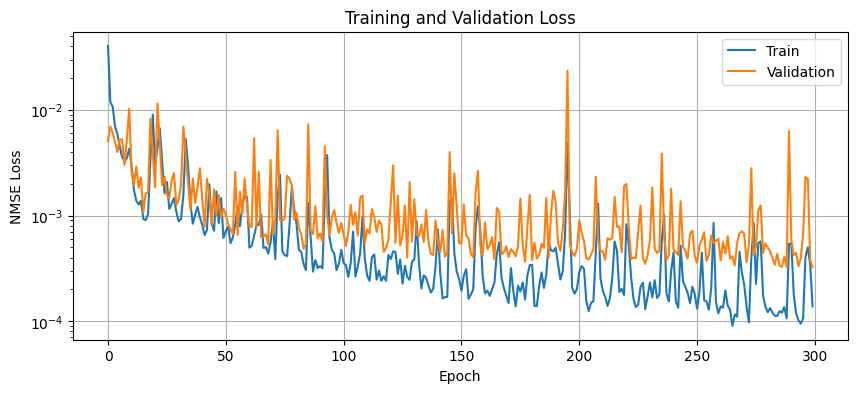


Final Test Results:
Mean test loss: 0.000855
Min test loss:  0.000030
Max test loss:  0.004667
Best val loss:  0.000324
Mean relative error U: 0.74%
Mean relative error V: 0.74%
Max relative error U:  2.69%
Max relative error V:  2.56%
Model vs Identity by Re range:
Re 0-50: Model=0.1873%, Identity=0.0000%, Improvement=-0.1872%
Re 50-100: Model=0.1803%, Identity=0.0010%, Improvement=-0.1793%
Re 100-150: Model=0.6411%, Identity=1.1468%, Improvement=0.5057%
Re 200-250: Model=0.4751%, Identity=2.3389%, Improvement=1.8638%
Re 250-300: Model=0.3842%, Identity=2.2885%, Improvement=1.9043%
Re 300-350: Model=0.7829%, Identity=3.3272%, Improvement=2.5443%
Re 350-400: Model=0.9327%, Identity=3.1681%, Improvement=2.2354%
Re 400-450: Model=1.2999%, Identity=3.0882%, Improvement=1.7882%


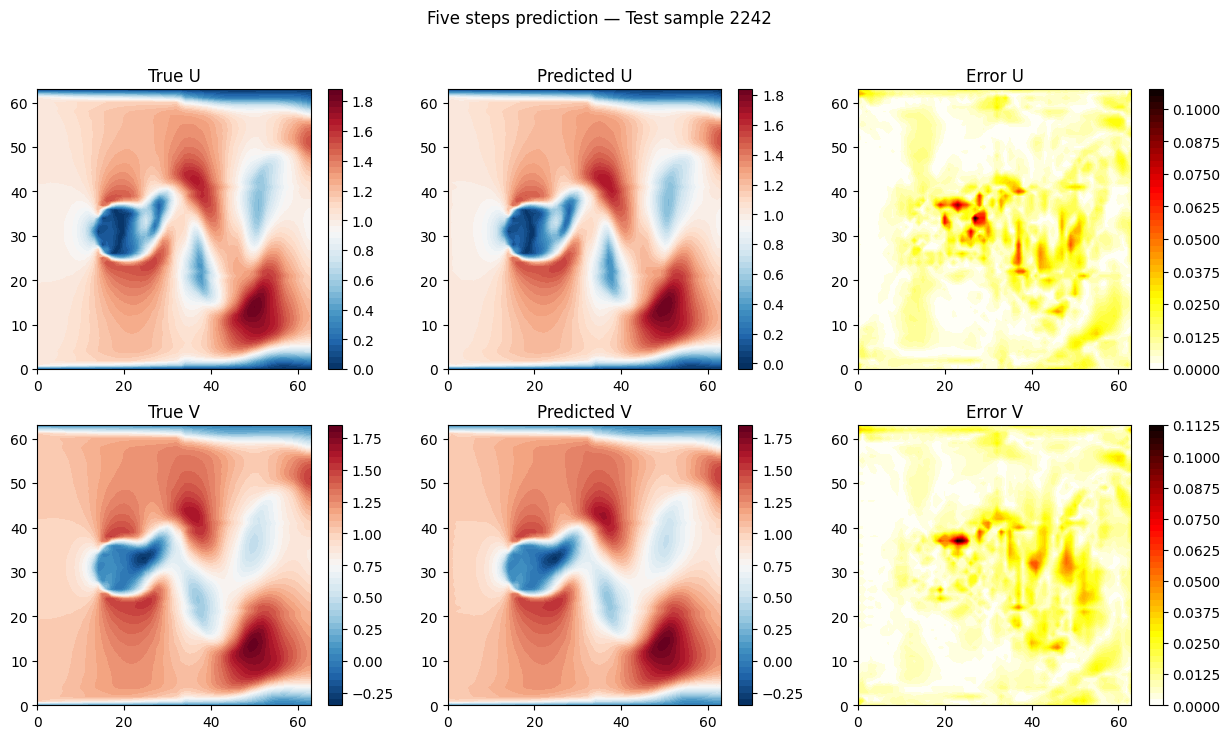

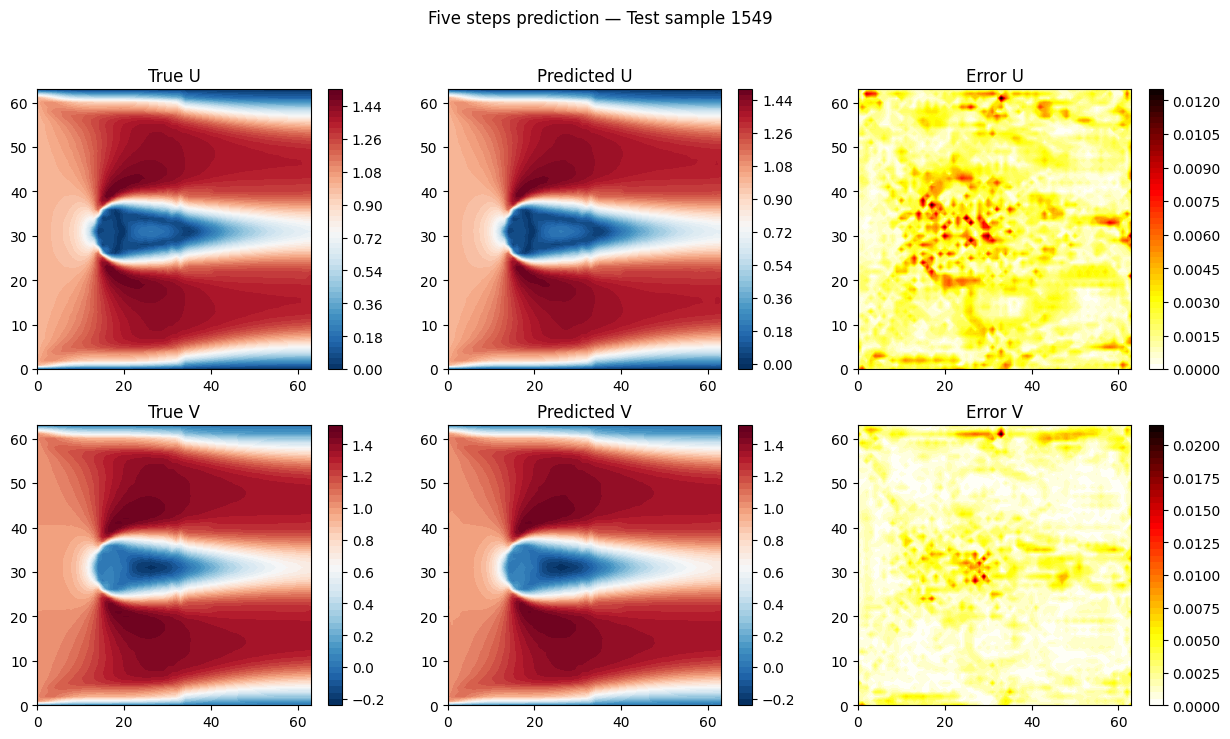

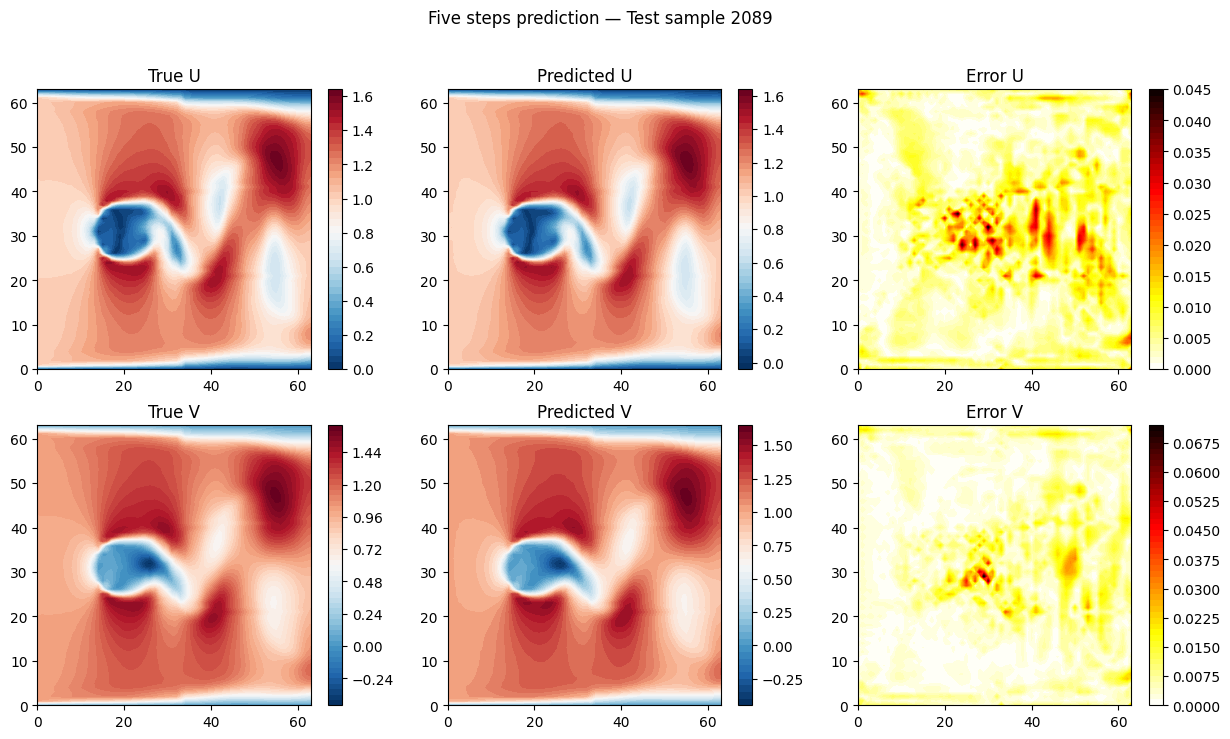

In [7]:
# GIVEN U_T PREDICT U_T+5

import os 
import numpy as np
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.optim as optim
import matplotlib.pyplot as plt
import random

base_path = r'C:\PyTorch\CNN_Cylinder'
subsets = ['bc', 'geo', 'prop']

# Per-subset time parameters
subset_params = {
    'bc':   {'T_START': 400, 'T_END': 613},
    'geo':  {'T_START': 1000, 'T_END': 1993},
    'prop': {'T_START': 600, 'T_END': 993}
}
DELTA_T     = 5
GRID        = 64
SAMPLE_STEP = 5

def create_mask(info, grid_size=GRID):
    x = np.linspace(info['x_min'], info['x_max'], grid_size)
    y = np.linspace(info['y_min'], info['y_max'], grid_size)
    X, Y = np.meshgrid(x, y)
    mask = (X**2 + Y**2 < info['radius']**2).astype(np.float32)
    return mask

# Load all cases
inputs_all  = []
targets_all = []
subset_ids  = []
case_ids    = []
subset_counts = {'bc': 0, 'geo': 0, 'prop': 0}

for subset in subsets:
    subset_path = os.path.join(base_path, subset)
    cases = sorted(os.listdir(subset_path))
    T_START = subset_params[subset]['T_START']
    T_END   = subset_params[subset]['T_END']
    print(f'Loading {subset}: {len(cases)} cases, T_START={T_START}, T_END={T_END}')
    
    for case in cases:
        json_path = os.path.join(subset_path, case, 'case.json')
        with open(json_path, 'r') as f:
            info = json.load(f)
        
        Re      = (info['density'] * info['vel_in'] * 2 * info['radius']) / info['viscosity']
        density = info['density']
        
        if density > 20 or Re > 400:
            continue
        
        mask       = create_mask(info)
        re_channel = np.full((GRID, GRID), Re, dtype=np.float32)
        
        u = np.load(os.path.join(subset_path, case, 'u.npy')) 
        v = np.load(os.path.join(subset_path, case, 'v.npy')) 
        
        for t in range(T_START, T_END, SAMPLE_STEP):
            u_t      = u[t].astype(np.float32)
            v_t      = v[t].astype(np.float32)
            u_t_next = u[t + DELTA_T].astype(np.float32)
            v_t_next = v[t + DELTA_T].astype(np.float32)
            
            inp = np.stack([mask, re_channel, u_t, v_t], axis=0)
            tgt = np.stack([u_t_next, v_t_next], axis=0)
            
            inputs_all.append(inp)
            targets_all.append(tgt)
            subset_ids.append(subset)
            case_ids.append(f'{subset}/{case}')
            subset_counts[subset] += 1

inputs_all  = np.array(inputs_all,  dtype=np.float32)
targets_all = np.array(targets_all, dtype=np.float32)

print(f'\nTotal samples:      {len(inputs_all)}')
print(f'Samples per subset: {subset_counts}')

# Train/val/test split — stratified by subset and viscosity group
unique_cases = list(dict.fromkeys(case_ids))
train_cases  = set()
val_cases    = set()
test_cases   = set()

# BC
bc_case_list = [c for c in unique_cases if c.startswith('bc')]
n = len(bc_case_list)
train_n = int(0.7 * n)
val_n   = int(0.1 * n)
train_cases.update(bc_case_list[:train_n])
val_cases.update(bc_case_list[train_n:train_n+val_n])
test_cases.update(bc_case_list[train_n+val_n:])
print(f'bc: {train_n} train, {val_n} val, {n-train_n-val_n} test')

# GEO
geo_case_list = [c for c in unique_cases if c.startswith('geo')]
n = len(geo_case_list)
train_n = int(0.7 * n)
val_n   = int(0.1 * n)
train_cases.update(geo_case_list[:train_n])
val_cases.update(geo_case_list[train_n:train_n+val_n])
test_cases.update(geo_case_list[train_n+val_n:])
print(f'geo: {train_n} train, {val_n} val, {n-train_n-val_n} test')

# PROP — per viscosity group
prop_by_viscosity = {}
prop_path = os.path.join(base_path, 'prop')
for case in sorted(os.listdir(prop_path)):
    case_key = f'prop/{case}'
    if case_key not in unique_cases:
        continue
    json_path = os.path.join(prop_path, case, 'case.json')
    with open(json_path, 'r') as f:
        info = json.load(f)
    visc = info['viscosity']
    if visc not in prop_by_viscosity:
        prop_by_viscosity[visc] = []
    prop_by_viscosity[visc].append(case_key)

for visc, cases in sorted(prop_by_viscosity.items()):
    n = len(cases)
    train_n = int(0.7 * n)
    val_n   = int(0.15 * n)
    train_cases.update(cases[:train_n])
    val_cases.update(cases[train_n:train_n+val_n])
    test_cases.update(cases[train_n+val_n:])
    print(f'prop visc={visc}: {train_n} train, {val_n} val, {n-train_n-val_n} test')

print(f'\nTotal train cases: {len(train_cases)}')
print(f'Total val cases:   {len(val_cases)}')
print(f'Total test cases:  {len(test_cases)}')

# Rebuild indices
train_idx = [i for i, c in enumerate(case_ids) if c in train_cases]
val_idx   = [i for i, c in enumerate(case_ids) if c in val_cases]
test_idx  = [i for i, c in enumerate(case_ids) if c in test_cases]

inputs_train  = inputs_all[train_idx]
targets_train = targets_all[train_idx]
inputs_val    = inputs_all[val_idx]
targets_val   = targets_all[val_idx]
inputs_test   = inputs_all[test_idx]
targets_test  = targets_all[test_idx]

print(f'\nTrain samples: {len(inputs_train)}')
print(f'Val samples:   {len(inputs_val)}')
print(f'Test samples:  {len(inputs_test)}')

# Normalization — train stats only
input_mean = inputs_train.mean(axis=(0, 2, 3), keepdims=True)
input_std  = inputs_train.std(axis=(0, 2, 3),  keepdims=True)
input_std  = np.where(input_std < 1e-6, 1.0, input_std)

u_mean, u_std = targets_train[:, 0].mean(), targets_train[:, 0].std()
v_mean, v_std = targets_train[:, 1].mean(), targets_train[:, 1].std()

# Normalize all splits using train stats
inputs_train_norm = (inputs_train - input_mean) / input_std
inputs_val_norm   = (inputs_val   - input_mean) / input_std
inputs_test_norm  = (inputs_test  - input_mean) / input_std

targets_train_norm = targets_train.copy()
targets_val_norm   = targets_val.copy()
targets_test_norm  = targets_test.copy()

targets_train_norm[:, 0] = (targets_train[:, 0] - u_mean) / u_std
targets_train_norm[:, 1] = (targets_train[:, 1] - v_mean) / v_std
targets_val_norm[:, 0]   = (targets_val[:, 0]   - u_mean) / u_std
targets_val_norm[:, 1]   = (targets_val[:, 1]   - v_mean) / v_std
targets_test_norm[:, 0]  = (targets_test[:, 0]  - u_mean) / u_std
targets_test_norm[:, 1]  = (targets_test[:, 1]  - v_mean) / v_std

print(f'\nInput means per channel: {input_mean.squeeze()}')
print(f'Input stds per channel:  {input_std.squeeze()}')
print(f'U: mean={u_mean:.4f}, std={u_std:.4f}')
print(f'V: mean={v_mean:.4f}, std={v_std:.4f}')

# Dataset class
class CylinderDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs  = torch.tensor(inputs,  dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

# Create datasets
train_dataset = CylinderDataset(inputs_train_norm, targets_train_norm)
val_dataset   = CylinderDataset(inputs_val_norm,   targets_val_norm)
test_dataset  = CylinderDataset(inputs_test_norm,  targets_test_norm)

# Weighted sampler for training
train_subset_ids     = [subset_ids[i] for i in train_idx]
subset_sample_counts = {s: train_subset_ids.count(s) for s in subsets}
print(f'\nTrain samples per subset: {subset_sample_counts}')

weights = torch.tensor(
    [1.0 / subset_sample_counts[s] for s in train_subset_ids],
    dtype=torch.float32
)
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1,  shuffle=False)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# U-Net architecture
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=2):
        super().__init__()
        self.enc1       = DoubleConv(in_channels, 32)
        self.enc2       = DoubleConv(32, 64)
        self.enc3       = DoubleConv(64, 128)
        self.bottleneck = DoubleConv(128, 256)
        self.up3        = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3       = DoubleConv(256, 128)
        self.up2        = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2       = DoubleConv(128, 64)
        self.up1        = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1       = DoubleConv(64, 32)
        self.output     = nn.Conv2d(32, out_channels, kernel_size=1)
        self.pool       = nn.MaxPool2d(2)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.output(d1)

# Device and model
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = UNet(in_channels=4, out_channels=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
def nmse_loss(pred, true):
    return torch.mean((pred - true)**2) / (torch.mean(true**2) + 1e-8)

criterion = nmse_loss
print(f'Training on: {device}')

# Training loop with validation and early stopping
epochs       = 300
patience     = 80
best_val_loss = float('inf')
counter      = 0
train_losses = []
val_losses   = []

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, targets)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Best Val Loss: {best_val_loss:.6f}, Counter: {counter}/{patience}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        # Save best model
        torch.save({
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses':         train_losses,
            'val_losses':           val_losses,
            'input_mean':           input_mean,
            'input_std':            input_std,
            'u_mean':               u_mean,
            'u_std':                u_std,
            'v_mean':               v_mean,
            'v_std':                v_std,
        }, r'C:\PyTorch\CNN_Cylinder\model_autoregressive_five_timesteps.pth')
    else:
        counter += 1
    
    if counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

# Load best model
checkpoint = torch.load(
    r'C:\PyTorch\CNN_Cylinder\model_autoregressive_five_timesteps.pth',
    weights_only=False
)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'\nBest val loss: {best_val_loss:.6f}')

# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel('Epoch')
plt.ylabel('NMSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

# Final test evaluation
model.eval()
test_losses = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        loss    = criterion(outputs, targets)
        test_losses.append(loss.item())

print(f'\nFinal Test Results:')
print(f'Mean test loss: {np.mean(test_losses):.6f}')
print(f'Min test loss:  {np.min(test_losses):.6f}')
print(f'Max test loss:  {np.max(test_losses):.6f}')
print(f'Best val loss:  {best_val_loss:.6f}')

# Visualize random test samples
sample_indices = random.sample(range(len(inputs_test_norm)), 3)

model.eval()
with torch.no_grad():
    for idx in sample_indices:
        inp = torch.tensor(inputs_test_norm[idx:idx+1], dtype=torch.float32).to(device)
        pred_norm = model(inp).cpu().numpy()[0]
        
        # Denormalize prediction
        pred = np.zeros_like(pred_norm)
        pred[0] = pred_norm[0] * u_std + u_mean
        pred[1] = pred_norm[1] * v_std + v_mean
        
        # Denormalize true target
        true_norm = targets_test_norm[idx]
        true = np.zeros_like(true_norm)
        true[0] = true_norm[0] * u_std + u_mean
        true[1] = true_norm[1] * v_std + v_mean
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        fig.suptitle(f'Five steps prediction — Test sample {idx}')
        
        for row, (field_true, field_pred, name) in enumerate(zip(
            [true[0], true[1]],
            [pred[0], pred[1]],
            ['U', 'V']
        )):
        # Use same color scale for true and predicted
            vmin = min(field_true.min(), field_pred.min())
            vmax = max(field_true.max(), field_pred.max())
    
            im0 = axes[row, 0].contourf(field_true, levels=50, cmap='RdBu_r', vmin=vmin, vmax=vmax)
            axes[row, 0].set_title(f'True {name}')
            plt.colorbar(im0, ax=axes[row, 0])
    
            im1 = axes[row, 1].contourf(field_pred, levels=50, cmap='RdBu_r', vmin=vmin, vmax=vmax)
            axes[row, 1].set_title(f'Predicted {name}')
            plt.colorbar(im1, ax=axes[row, 1])
    
            error = np.abs(field_pred - field_true)
            im2 = axes[row, 2].contourf(error, levels=50, cmap='hot_r')
            axes[row, 2].set_title(f'Error {name}')
            plt.colorbar(im2, ax=axes[row, 2])

model.eval()
rel_errors_u = []
rel_errors_v = []

with torch.no_grad():
    for idx in range(len(inputs_test_norm)):
        inp = torch.tensor(inputs_test_norm[idx:idx+1], dtype=torch.float32).to(device)
        pred_norm = model(inp).cpu().numpy()[0]
        
        pred_u = pred_norm[0] * u_std + u_mean
        pred_v = pred_norm[1] * v_std + v_mean
        true_u = targets_test[idx, 0]
        true_v = targets_test[idx, 1]
        
        rel_u = np.mean(np.abs(pred_u - true_u)) / (np.mean(np.abs(true_u)) + 1e-8) * 100
        rel_v = np.mean(np.abs(pred_v - true_v)) / (np.mean(np.abs(true_v)) + 1e-8) * 100
        
        rel_errors_u.append(rel_u)
        rel_errors_v.append(rel_v)

print(f'Mean relative error U: {np.mean(rel_errors_u):.2f}%')
print(f'Mean relative error V: {np.mean(rel_errors_v):.2f}%')
print(f'Max relative error U:  {np.max(rel_errors_u):.2f}%')
print(f'Max relative error V:  {np.max(rel_errors_v):.2f}%')

# Identity baseline by Re range
identity_errors_by_re = {}

for idx in range(len(inputs_test)):
    re_val = inputs_test[idx, 1, 0, 0]
    
    u_identity = inputs_test[idx, 2]
    true_u     = targets_test[idx, 0]
    
    rel_id = np.mean(np.abs(u_identity - true_u)) / (np.mean(np.abs(true_u)) + 1e-8) * 100
    
    re_bin = int(re_val / 50) * 50
    if re_bin not in identity_errors_by_re:
        identity_errors_by_re[re_bin] = []
    identity_errors_by_re[re_bin].append(rel_id)

# Then model evaluation by Re range
model_errors_by_re = {}

model.eval()
with torch.no_grad():
    for idx in range(len(inputs_test_norm)):
        re_val = inputs_test[idx, 1, 0, 0]
        
        inp = torch.tensor(inputs_test_norm[idx:idx+1], dtype=torch.float32).to(device)
        pred_norm = model(inp).cpu().numpy()[0]
        
        pred_u = pred_norm[0] * u_std + u_mean
        true_u = targets_test[idx, 0]
        
        rel_model = np.mean(np.abs(pred_u - true_u)) / (np.mean(np.abs(true_u)) + 1e-8) * 100
        
        re_bin = int(re_val / 50) * 50
        if re_bin not in model_errors_by_re:
            model_errors_by_re[re_bin] = []
        model_errors_by_re[re_bin].append(rel_model)

# Print comparison
print('Model vs Identity by Re range:')
for re_bin in sorted(model_errors_by_re.keys()):
    model_err    = np.mean(model_errors_by_re[re_bin])
    identity_err = np.mean(identity_errors_by_re.get(re_bin, [0]))
    improvement  = identity_err - model_err
    print(f'Re {re_bin}-{re_bin+50}: Model={model_err:.4f}%, Identity={identity_err:.4f}%, Improvement={improvement:.4f}%')            